# PharmFlux quickstart and user guide for Python

Build a unit-aware model, simulate a dosing regimen, compare parameters, and fit
synthetic observations using PharmFlux's native Python binding. The examples
run locally and require no Ubi account or simulation service. All parameter
values and data in this guide are synthetic.

This guide targets the source-based 0.1.0 API. Python metadata requires Python
3.10 or later; that requirement is not a guarantee that every Python version
and operating system has been tested. Use the installation instructions supplied
with your source checkout or wheel. These instructions do not assume a PyPI
release exists. Run the notebook cells from top to bottom with a kernel that has PharmFlux, pandas, and matplotlib installed. Installation commands below are reference instructions and are not executed by the notebook. The complete
[example script](examples/python_quickstart.py) runs the same workflow without
optional plotting dependencies. This notebook includes the plotting example and keeps its rendered output.

## Contents

1. [Install and verify](#install-and-verify)
2. [Quickstart](#quickstart)
3. [Read and plot results](#read-and-plot-results)
4. [Change parameters and dosing](#change-parameters-and-dosing)
5. [Choose sampling and solver settings](#choose-sampling-and-solver-settings)
6. [Scan parameters](#scan-parameters)
7. [Calculate sensitivities and Morris screening](#calculate-sensitivities-and-morris-screening)
8. [Fit an individual model](#fit-an-individual-model)
9. [Fit one parameter without sensitivities](#fit-one-parameter-without-sensitivities)
10. [Fit population data](#fit-population-data)
11. [Save a reproducible analysis](#save-a-reproducible-analysis)
12. [Handle errors and troubleshoot](#handle-errors-and-troubleshoot)
13. [API reference and further reading](#api-reference-and-further-reading)

## Install and verify

You need a complete PharmFlux source checkout, Python, Rust/Cargo, and a native
compiler toolchain. The R binding declares Rust 1.98 or later; using that
toolchain also keeps a shared checkout consistent. Build from the repository
root, where `pyproject.toml`, `Cargo.toml`, and `Cargo.lock` live.

```sh
python3 -m venv .venv
# macOS or Linux
source .venv/bin/activate
# Windows PowerShell instead: .venv\Scripts\Activate.ps1
python -m pip install maturin==1.15.0
maturin develop --release --locked
python -c "import pharmflux; print(pharmflux.__version__)"
```

The last command should print `0.1.0` for this source version. Initial builds
need network access to download locked dependencies. Once cached, use
`maturin develop --release --locked --offline`. Offline mode does not download
missing dependencies.

To create a wheel instead of installing into an active virtual environment:

```sh
maturin build --release --locked --out dist
# Replace the filename with the wheel produced for your environment.
python -m pip install dist/PHARMFLUX_WHEEL_FILENAME.whl
```

Keep the complete workspace and vendored solver source together. Copying only
`bindings/python` does not supply the Rust workspace it depends on. In Jupyter,
select the kernel from the environment where the package was installed, and
restart it after replacing the native extension.

## Quickstart

Our model has a central drug amount `central` in mg, clearance `cl` in L/h,
and volume `v` in L. Its equations are
`dA/dt = input - (cl/v) A` and `cp = A/v`. A bolus of 6 mg in a 3 L volume
gives 2 mg/L immediately after dosing. The elimination rate is 0.1 per hour.

### Compile the model

### Notebook execution setup

Run the cells in order. Generated files go into `pharmflux-python-tutorial-output` beneath the directory where the notebook kernel starts. Package installation is a separate prerequisite.

In [1]:
from pathlib import Path
import os

analysis_directory = Path.cwd() / "pharmflux-python-tutorial-output"
analysis_directory.mkdir(exist_ok=True)
os.chdir(analysis_directory)
print("Analysis files are saved in pharmflux-python-tutorial-output.")

Analysis files are saved in pharmflux-python-tutorial-output.


In [2]:
import copy
import csv
import json
import math
from pathlib import Path

import pharmflux
from pharmflux import (
    CompiledModel, CompiledSensitivities, PharmfluxError,
    format_model, population_fit_dataset,
)

source = """model quickstart_one_compartment
time_unit = h
parameters
  cl = 0.3 [L/h] log
  v = 3 [L] log
states
  central = 0 [mg]
dynamics
  d/dt(central) = input_central - cl / v * central
outputs
  cp = central / v [mg/L]
dosing
  central [mg] = 1
end
"""

model = CompiledModel(source)
print(model.output_names, model.output_units)

def q(value, unit):
    return {"value": value, "unit": unit}

['cp'] ['mg/L']


The dosing declaration enables amount delivery to `central`; `input_central`
allows infusion forcing in the differential equation. Without that term, an
infusion would not implement the intended input. Model text, JSON model text,
and model dictionaries are accepted by `CompiledModel`. A filename is not
model text: load a file with `Path("model.pfx").read_text(encoding="utf-8")`.

### Define the experiment and run it

Use explicit observations to select exactly the requested times and event
sides. This also makes fitting row numbers straightforward later.

In [3]:
times = [0, 1, 2, 4, 8, 12]
request = {
    "schema": "pharmflux.run/v0.1",
    "solver": "diffsol_bdf",
    "budgets": {"solver_callbacks": 1_000_000,
                "events": 100, "output_values": 10_000},
    "regimen": {
        "end": q(12, "h"),
        "samples": [],
        "observations": [{"time": q(t, "h"), "side": "post"}
                         for t in times],
        "administrations": [{
            "target": "central", "time": q(0, "h"),
            "amount": q(6, "mg"), "delivery": {"kind": "bolus"},
            "bioavailability": 1.0,
        }],
        "rtol": 1e-10, "atol": 1e-12,
    },
}
result = model.run(request)
cp = next(column for column in result["outputs"] if column["name"] == "cp")
assert result["times"] == times
assert result["sides"] == ["post"] * len(times)
for t, value in zip(result["times"], cp["values"]):
    assert abs(value - 2 * math.exp(-0.1 * t)) < 1e-8
print(list(zip(result["times"], cp["values"])))

[(0.0, 2.0), (1.0, 1.8096748360733907), (2.0, 1.637461506229269), (4.0, 1.3406400923108588), (8.0, 0.8986579286351024), (12.0, 0.6023884242521202)]


Expected concentrations include 2.000000 mg/L at 0 h, 1.340640 mg/L at 4 h,
and 0.602388 mg/L at 12 h. These checks compare against the analytic solution,
so they verify more than successful execution.

Compile once and reuse `model`. Each call binds an independent request; it
does not continue the state from the preceding call. A supplied `initial_states`
map overrides initial conditions explicitly.

## Read and plot results

Results contain `times`, `sides`, `time_unit`, named `outputs` with `unit` and
`values`, and `identity`. States appear only when exposed as outputs. Never
assume the first output is the one you need, and retain side labels at event
times. Build a long table without adding a dependency:

In [4]:
def result_rows(answer):
    return [
        {"TIME": t, "SIDE": side, "OUTPUT": column["name"],
         "VALUE": value, "UNIT": column["unit"]}
        for column in answer["outputs"]
        for t, side, value in zip(answer["times"], answer["sides"],
                                  column["values"])
    ]

table = result_rows(result)
with open("trajectory.csv", "w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(table[0]))
    writer.writeheader()
    writer.writerows(table)

For pandas and matplotlib, install them in the same environment with
`python -m pip install pandas matplotlib`, then optionally run:

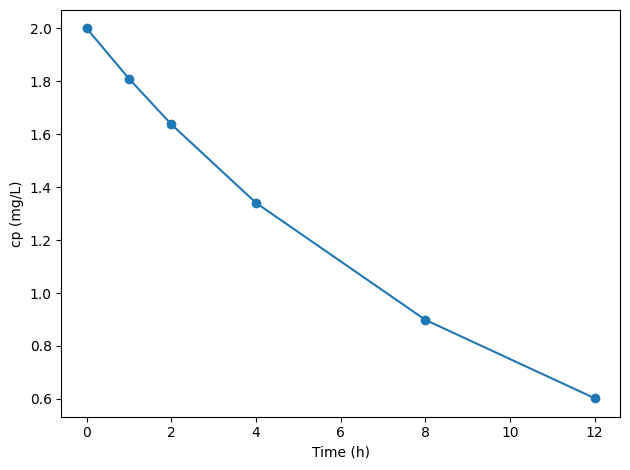

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

frame = pd.DataFrame(table)
selected = frame[(frame["OUTPUT"] == "cp") & (frame["SIDE"] == "post")]
plt.plot(selected["TIME"], selected["VALUE"], marker="o")
plt.xlabel(f"Time ({result['time_unit']})")
plt.ylabel(f"cp ({cp['unit']})")
plt.tight_layout()
plt.savefig("trajectory.png", dpi=150)
plt.show()
plt.close()

CSV preserves the tabular values, but not the full scientific identity. Save
the JSON result as well. Missing values, if present in a serialized result,
are not zero; preserve them when preparing tables.

## Change parameters and dosing

Copy nested requests before editing them. A shallow `dict.copy()` still shares
its nested regimen with the original.

In [6]:
changed = copy.deepcopy(request)
changed["parameters"] = {"cl": q(0.6, "L/h"), "v": q(3, "L")}
faster_clearance = model.run(changed)

repeated = copy.deepcopy(request)
repeated["regimen"]["administrations"][0]["repeat"] = {
    "interval": q(4, "h"), "additional": 2,
}
repeated_result = model.run(repeated)  # Doses at 0, 4, and 8 h.

infusion = copy.deepcopy(request)
infusion["regimen"]["administrations"][0]["delivery"] = {
    "kind": "infusion",
    "span": {"kind": "duration", "duration": q(2, "h")},
}
infusion_result = model.run(infusion)  # 6 mg over 2 h: 3 mg/h before F.

`additional` counts doses after the first. A rate-based infusion instead uses
`span = {"kind": "rate", "rate": q(3, "mg/h")}`; supply either rate or
duration. `bioavailability` is a fraction from 0 to 1 applied to the dose.
Request lag and any model-declared lag add to the administration time. Keep
all deliveries within the experiment horizon and use a declared dosing target.

Amounts, volumes, and concentrations have different dimensions. Compatible
unit conversions such as ug to mg are supported; an amount cannot substitute
for a concentration without a volume or a declared dosing scale. Do not infer
units from a variable name. Inspect the [unit specification](../spec/units.md)
before introducing a new unit spelling.

For covariates, declare them in the model and supply quantities through
`regimen.covariates`; step covariates can also use `covariate_changes`.
Override base parameters rather than derived `individual` expressions.
Constant and step numeric covariates are supported; categorical covariates and
linear interpolation are outside the current model contract.

### Build an oral two compartment model

For first-order absorption and central/peripheral distribution, add a depot,
an intercompartmental clearance, and a peripheral volume. This independently
written synthetic model exposes amounts as well as concentration so you can
inspect where the drug resides.

In [7]:
oral_source = """model quickstart_oral_two_compartment
time_unit = h
parameters
  cl = 1 [L/h] log
  vc = 5 [L] log
  vp = 10 [L] log
  exchange = 0.5 [L/h] log
  ka = 1 [1/h] log
states
  depot = 0 [mg]
  central = 0 [mg]
  peripheral = 0 [mg]
dynamics
  d/dt(depot) = -ka * depot
  d/dt(central) = ka * depot - cl / vc * central - exchange * (central / vc - peripheral / vp)
  d/dt(peripheral) = exchange * (central / vc - peripheral / vp)
outputs
  cp = central / vc [mg/L]
  depot_amount = depot [mg]
  central_amount = central [mg]
  peripheral_amount = peripheral [mg]
dosing
  depot [mg] bolus = 1
end
"""
oral_model = CompiledModel(oral_source)
oral_request = copy.deepcopy(request)
oral_dose = oral_request["regimen"]["administrations"][0]
oral_dose["target"] = "depot"
oral_dose["amount"] = q(100, "mg")
oral_dose["bioavailability"] = 0.8
oral_result = oral_model.run(oral_request)
oral_columns = {column["name"]: column for column in oral_result["outputs"]}
assert oral_columns["cp"]["values"][0] == 0
assert oral_columns["depot_amount"]["values"][0] == 80
assert all(value >= -1e-8 for column in oral_result["outputs"]
           for value in column["values"])

The depot receives the available 80 mg and transfers it to central by first-order
absorption. The model permits bolus input only to the depot; it does not have
an infusion term there. Summing the three amount derivatives cancels internal
transfer and leaves central elimination. This is an assumption about a simple
mechanism, not a drug-specific oral PK model or a model of saturable absorption.
For larger PBPK/QSP systems, expose relevant state amounts, check conservation
and domains, and choose state-specific absolute tolerances.

## Choose sampling and solver settings

At a bolus time, `pre` means before the jump and `post` means after it. The
same-time record order in a dataset does not choose a side for you.

In [8]:
at_dose = copy.deepcopy(request)
at_dose["regimen"]["observations"] = [
    {"time": q(0, "h"), "side": "pre"},
    {"time": q(0, "h"), "side": "post"},
]
event_result = model.run(at_dose)
assert event_result["outputs"][0]["values"] == [0.0, 2.0]

Explicit observations preserve request order and duplicates. Without an
observation plan, use `samples` to request trajectory sampling; event boundaries
can add rows. Inspect the returned times and sides rather than deriving row
numbers from the samples list. Do not combine nonempty `samples` with
`observations`, or send an explicitly empty observation plan.

The quickstart uses BDF. Simulation also supports `diffsol_tsit45`,
`diffsol_esdirk34`, `diffsol_tr_bdf2`, `diffsol_rosenbrock23`, and
`diffsol_rodas5p` for their supported ODE scope. Select a method appropriate
to the model and verify tolerance convergence; no unknown solver selects a
fallback. Sensitivities and sensitivity-based fitting currently require BDF.
`analytic_linear_pk` requires a model with a `linear_pk` declaration; it does
not automatically recognize arbitrary ODE text as linear PK.

`rtol` is dimensionless. Scalar `atol` uses each state's numeric unit. For
states with different scales, replace `atol` with `absolute_tolerances`, a
quantity map covering every state, for example `{"central": q(1e-12, "mg")}`.
Use exactly one absolute-tolerance mode. Budgets bound callbacks, events and
stored outputs; they are work limits, not wall-clock timeouts. Increasing
budgets does not fix an invalid equation or poor identifiability.

## Scan parameters

A scan evaluates explicit parameter points. It supports at most 25 runs, with
per-run budgets in `run` and aggregate budgets in `total_budgets`.

In [9]:
scan_request = {
    "schema": "pharmflux.scan/v0.1", "run": copy.deepcopy(request),
    "points": [{"id": f"cl_{value}", "parameters": {"cl": q(value, "L/h")}}
               for value in [0.3, 0.6, 1.2]],
    "total_budgets": {"solver_callbacks": 3_000_000,
                      "events": 300, "output_values": 30_000},
}
scan = model.scan(scan_request)
for point in scan["results"]:
    print(point["id"], point["parameters"],
          point["result"]["outputs"][0]["values"][-1])

cl_0.3 {'cl': {'value': 0.3, 'unit': 'L/h'}} 0.6023884242521202
cl_0.6 {'cl': {'value': 0.6, 'unit': 'L/h'}} 0.18143590662758488
cl_1.2 {'cl': {'value': 1.2, 'unit': 'L/h'}} 0.01645949414928955


Points need unique IDs and valid units. Choose scientifically justified ranges;
a parameter scan is a deterministic scenario comparison, not a confidence
interval or population distribution.

## Calculate sensitivities and Morris screening

Forward sensitivities calculate output derivatives for an ordered parameter
selection. Compile that selection once; subsequent requests must use the same
order. Derivative tolerances carry state-unit divided by parameter-unit.

In [10]:
sensitivity_request = {
    "schema": "pharmflux.sensitivity/v0.1",
    "run": copy.deepcopy(request), "with_respect_to": ["cl", "v"],
    "derivative_absolute_tolerances": {
        "cl": {"central": q(1e-12, "mg.h/L")},
        "v": {"central": q(1e-12, "mg/L")},
    },
}
sensitive = CompiledSensitivities(source, ["cl", "v"])
sensitivities = sensitive.run(sensitivity_request)
for column in sensitivities["derivatives"]:
    print(column["parameter"], column["output"], column["unit"])

cl cp (mg/L)/(L/h)
v cp (mg/L)/(L)


These are local derivatives, not parameter uncertainty. For screening over
chosen ranges, Morris calculates elementary effects at a selected output row.
With two parameters and two trajectories, this example uses six runs.

In [11]:
morris_request = {
    "schema": "pharmflux.morris/v0.1",
    "problem": {"kind": "generated", "request": {
        "run": copy.deepcopy(request),
        "ranges": [
            {"parameter": "cl", "lower": q(0.1, "L/h"), "upper": q(0.7, "L/h")},
            {"parameter": "v", "lower": q(3, "L"), "upper": q(6, "L")},
        ],
        "trajectory_count": 2, "num_levels": 4, "seed": 42,
        "total_budgets": {"solver_callbacks": 6_000_000,
                          "events": 600, "output_values": 60_000},
        "output": "cp", "row": 3,  # Zero-based: our selected 4 h row.
    }},
}
morris = model.morris(morris_request)
for effect in morris["result"]["effects"]:
    print(effect["parameter"], effect["mu_star"], effect["sigma"])

cl 0.3917484260052081 0.08949838425713687
v 0.6269037762976375 0.47659952684092843


`mu_star` describes average effect magnitude; `sigma` describes variation among
the elementary effects. Results depend on the ranges, grid, seed, and chosen
readout. The 25-run scan limit also bounds Morris designs.

## Fit an individual model

An individual fit estimates selected shared model parameters against measured
outputs. This demonstration generates exact synthetic observations with
`cl = 0.6 L/h` and `v = 4.5 L`, and uses a fixed additive normal SD of
0.1 mg/L. Real data require a justified error model and sampling design.

In [12]:
observations = [
    {"row": row, "output": "cp",
     "value": q(6 / 4.5 * math.exp(-0.6 * t / 4.5), "mg/L"),
     "error": {"additive_sd": q(0.1, "mg/L"), "proportional_sd": 0.0}}
    for row, t in enumerate(times)
]
fit_request = {
    "schema": "pharmflux.fit/v0.1",
    "problem": {"kind": "individual", "request": {
        "objective": {"simulation": copy.deepcopy(sensitivity_request),
                      "observations": observations, "priors": []},
        "bounds": [
            {"parameter": "cl", "lower": q(0.05, "L/h"), "upper": q(1.2, "L/h")},
            {"parameter": "v", "lower": q(1, "L"), "upper": q(8, "L")},
        ],
        "max_evaluations": 400, "max_iterations": 100,
        "gradient_tolerance": 1e-5,
    }},
}
fitted = sensitive.fit(fit_request)
fit = fitted["fit"]
print(fit["status"], fit["parameters"])
assert fit["status"] == "converged", fit
assert abs(fit["parameters"]["cl"]["value"] - 0.6) < 1e-4
assert abs(fit["parameters"]["v"]["value"] - 4.5) < 1e-4

replay = copy.deepcopy(request)
replay["parameters"] = fit["parameters"]
fit_predictions = model.run(replay)

converged {'cl': {'value': 0.5999999990625422, 'unit': 'L/h'}, 'v': {'value': 4.500000000360862, 'unit': 'L'}}


`row` is zero-based in the simulation result, even if another tool uses
one-based indexing. The explicit observation plan here ensures that `row = 0`
is the post-dose measurement at 0 h. Duplicate observations remain separate
likelihood contributions. Parameter bounds and error SDs must carry compatible
units. `priors = []` requests likelihood fitting; supported priors produce MAP
fits. Consult the [Gaussian objective specification](GAUSSIAN-OBJECTIVE.md)
before changing the observation model or adding priors.

Returning a fit does not imply convergence. Inspect status, objective,
evaluation count, parameter bounds, and a replay at final estimates. A result
with `evaluation_limit` is incomplete. Small residuals alone do not establish
identifiability. Pooled fits share parameter estimates across subjects without
random effects; see the versioned fit schema for the `pooled` envelope.

## Fit one parameter without sensitivities

`fit_scalar` searches one bounded parameter by native simulation when compiling
sensitivities is impractical. Fix all other parameters explicitly. This example
fixes `v` at the synthetic truth so only clearance needs estimation.

In [13]:
scalar_run = copy.deepcopy(request)
scalar_run["parameters"] = {"v": q(4.5, "L")}
scalar_request = {
    "schema": "pharmflux.scalar-fit/v0.1", "run": scalar_run,
    "parameter": "cl", "lower": q(0.1, "L/h"), "upper": q(1, "L/h"),
    "observations": copy.deepcopy(observations),
    "max_iterations": 80, "absolute_tolerance": 1e-7,
}
scalar = model.fit_scalar(scalar_request)
print(scalar["status"], scalar["parameters"], scalar["evaluations"])
assert scalar["status"] == "converged"
assert abs(scalar["parameters"]["cl"]["value"] - 0.6) < 1e-4

converged {'cl': {'value': 0.5999999807138922, 'unit': 'L/h'}} 11


The scalar result stores `status` at the top level, whereas the preceding
individual result stores it under `fit`. The search tolerance is expressed on
the selected parameter's numeric scale. This contract fits independent additive
normal observations; it does not support priors, censoring, proportional error,
or a joint multi-parameter search.

## Fit population data

The dataset adapter accepts a list of row dictionaries or a pandas data frame.
It converts an explicit subset of NONMEM-style records into one population
request. A dose compartment and an observation endpoint are separate mappings.
The following four-subject example estimates typical clearance with a lognormal
subject effect. Volume and the eta variance are fixed for this demonstration;
it does not estimate a full population PK model.

In [14]:
rows = []
for index, eta in enumerate([-0.22, -0.08, 0.08, 0.22], start=1):
    subject_id = f"S{index}"
    rows.append({"ID": subject_id, "TIME": 0, "EVID": 1,
                 "CMT": 1, "AMT": 6, "MDV": 1})
    for t in [1, 2, 4]:
        rows.append({"ID": subject_id, "TIME": t, "EVID": 0,
                     "CMT": 2, "AMT": 0, "MDV": 0,
                     "DV": 6 / 4.5 * math.exp(-0.6 * math.exp(eta) * t / 4.5)})

pop_sensitivity = copy.deepcopy(sensitivity_request)
pop_sensitivity["with_respect_to"] = ["cl"]
pop_sensitivity["derivative_absolute_tolerances"].pop("v")
pop_run = pop_sensitivity["run"]
pop_run["parameters"] = {"cl": q(0.5, "L/h"), "v": q(4.5, "L")}
pop_run["regimen"]["samples"] = []
pop_run["regimen"].pop("observations")
pop_run["regimen"]["administrations"] = []

population_template = {
    "schema": "pharmflux.fit/v0.1",
    "problem": {"kind": "focei", "request": {
        "subjects": [{"simulation": pop_sensitivity,
                      "observations": [], "priors": []}],
        "fixed_effects": [{"parameter": "cl", "lower": q(0.35, "L/h"),
                           "upper": q(0.85, "L/h")}],
        "random_effects": [{"parameter": "cl"}],
        "omega": [[0.04]], "omega_diagonal_bounds": [[0.04, 0.04]],
        "eta_bound": 1.5, "max_evaluations": 30_000,
        "max_iterations": 80, "gradient_tolerance": 0.005, "seed": 17,
    }},
}
endpoints = {2: {"output": "cp", "value_unit": "mg/L", "error": {
    "additive_sd": q(0.05, "mg/L"), "proportional_sd": 0.0,
}}}
dataset = population_fit_dataset(
    rows, population_template, compartments={1: "central"},
    endpoints=endpoints, time_unit="h", amount_unit="mg",
    observation_side="post",
)
population_model = CompiledSensitivities(source, ["cl"])
population_fit = population_model.fit_population_data(dataset)
population = population_fit["result"]["population"]
print(population["status"], population["objective_kind"])
print(population["fixed_effects"], population["omega"])
assert population["status"] == "converged"
assert abs(population["fixed_effects"]["cl"]["value"] - 0.6) < 0.06

converged focei_objective_function_value
{'cl': {'value': 0.6, 'unit': 'L/h'}} [[0.04]]


For an actual CSV workflow, load the file before preparation, preserving string
subject IDs and explicit missing-value flags:

In [15]:
# Requires pandas; replace rows with your own validated data.
# rows = pd.read_csv("observations.csv", dtype={"ID": "string"})
# Check TIME/AMT/DV numeric types, CMT mappings, MDV and units before fitting.

Review `dataset.request` before execution. `dataset.mapping` and
`population_fit["mapping"]` preserve zero-based `source_row`, `result_row`,
and subject indices. `subject_ids` follow first appearance in the input.
FOCEI fitted observations include PRED/IPRED and the mapped source rows; retain
these mappings when joining predictions back to data.

Supported columns are `ID`, `TIME`, `EVID`, `DV`, `MDV`, `AMT`, `CMT`, `RATE`,
`ADDL`, `II`, and `SS`. `EVID = 0`, `MDV = 0` includes a measurement;
`MDV = 1` excludes it. Included `DV` must be finite. `EVID = 1` is a dose.
`RATE = 0` is bolus; positive RATE is a finite infusion and requires an explicit
`rate_unit`, such as `mg/h`. ADDL/II expand repeats. Nonzero SS, EVID 2/3/4,
negative RATE, unknown columns such as WT, and dose fields on observation rows
are rejected. The template horizon is not extended to fit the rows.

### Use SAEM and interpret its status

SAEM uses the same prepared-data interface with `problem.kind = "saem"`.
This deliberately short example demonstrates an iteration-limited result;
eight iterations are not a recommended estimation budget.

In [16]:
saem_template = copy.deepcopy(population_template)
saem_template["problem"]["kind"] = "saem"
saem_template["problem"]["request"]["max_iterations"] = 8
saem_dataset = population_fit_dataset(
    rows, saem_template, compartments={1: "central"}, endpoints=endpoints,
    time_unit="h", amount_unit="mg", observation_side="post",
)
saem_fit = population_model.fit_population_data(saem_dataset)
saem = saem_fit["result"]["population"]
print(saem["status"], saem["objective_kind"])

iteration_limit saem_marginal_objective_function_value


A converged SAEM result reports `saem_marginal_objective_function_value`.
A limited run can report `saem_complete_data_surrogate`; these objective
values are not interchangeable. Fitted observation rows can be absent in an
incomplete SAEM result; inspect the field instead of assuming a diagnostics
table exists. The [SAEM guide](SAEM.md) describes one- and two-effect
lognormal subject effects with Gaussian residual error and the supported
common additive-error estimation. This public version does not support
lognormal observation errors, censored observations, a fitted-covariate
request field, or SAEM uncertainty. The row adapter does not infer them.
Record the seed, repeat seeds when assessing stability, and verify recovery
for your own equation class and cohort design.

## Save a reproducible analysis

Save model source, actual requests, complete results, data mappings, and the
package version. CSV or a screenshot alone cannot reproduce an analysis.

In [17]:
bundle = Path("pharmflux-analysis")
bundle.mkdir(exist_ok=True)
(bundle / "model.pfx").write_text(source, encoding="utf-8")
(bundle / "model.canonical.pfx").write_text(format_model(source), encoding="utf-8")
artifacts = {
    "run.request.json": request, "run.result.json": result,
    "fit.request.json": fit_request, "fit.result.json": fitted,
    "population.request.json": dataset.request,
    "population.result.json": population_fit,
    "population.rows.json": rows,
    "software.json": {"pharmflux": pharmflux.__version__},
}
for filename, value in artifacts.items():
    (bundle / filename).write_text(
        json.dumps(value, indent=2, allow_nan=False) + "\n", encoding="utf-8")
print(result["identity"])

{'model_content_hash': 'sha256:75afccc84e2f2c1448a5432dec62406b7067dbb68b51b2882d98aa89e3cf1a6d', 'spec_version': 'pharmflux.spec/0.1', 'compiler_version': 'pharmflux/0.1.0', 'compiler_source_sha256': 'sha256:3d60dca0248b6cf661225b81a9c45e6419204da5bc25cc3e4c5c63d2918c1818', 'rustc_version': 'rustc 1.98.1 (48a229cea 2026-09-01) (Homebrew)', 'target': 'aarch64-apple-darwin', 'build_profile': 'release', 'rustflags_sha256': 'sha256:c413dbb143aa3e09845350d664f4abc382d6f94ce0f8c67a2f6c6aff8d68656b', 'bound_value_hash': 'sha256:3acc58471af74194008bde05ff3dfccd5d9baeec34d29d91468ea8865e13bb17', 'run_request_hash': 'sha256:4a248f684ef29c4fbbaac25049116180b45a92337113a8e099fc6879f4c3cf65', 'backend': 'diffsol', 'backend_version': '0.17.1+sha256:c182fd25086e064bf9186282ae9db23981e39b3720cba12372ca9cd5e833fb9f', 'algorithm': 'bdf'}


Identity records model content, resolved binding, run request, compiler source
and backend/build information. It identifies the executed inputs and engine;
it does not certify the scientific suitability of the model. Native build
targets can differ while sharing scientific content hashes.

Compiled objects belong to a live process. Recompile from saved source in a
new process rather than treating a serialized object as a portable model.
Compiled Python models can serve independent threads; native work releases
the GIL. Returned values are ordinary Python lists and dictionaries, not a
zero-copy NumPy interface. Limit concurrency explicitly. Cancelling a Python
future does not interrupt an active native solve; hard deadlines require a
supervising process.

## Handle errors and troubleshoot

Catch structured scientific errors at the operation boundary. The full
diagnostic can contain a code, scientific time, expression, and source location.
Some diagnostics use a fallback location; do not assume every line/column is
an exact expression span.

In [18]:
invalid = copy.deepcopy(request)
invalid["parameters"] = {"cl": q(1, "h")}
try:
    model.run(invalid)
except PharmfluxError as error:
    print(error.code, str(error))
    print(error.diagnostic)
else:
    raise AssertionError("incompatible clearance units were accepted")
assert model.run(request) == result  # The failed request did not alter the model.

unit incompatible dimensions; mass/amount conversion requires explicit molar mass
{'code': 'unit', 'expression': None, 'message': 'incompatible dimensions; mass/amount conversion requires explicit molar mass', 'time': None}


| Symptom | Action |
| --- | --- |
| Import fails after installation | Check `sys.executable`, virtual environment or notebook kernel, and wheel compatibility. |
| Build cannot find Cargo or native tools | Install the required toolchain and build from the complete workspace root. |
| Offline build cannot resolve dependencies | Fetch locked dependencies online before requesting offline execution. |
| Unit or unknown-symbol error | Compare declarations and quantity units; use `input_<state>` only in supported contexts. |
| Wrong value at a dose time | Inspect `sides` and explicitly request `pre` or `post`. |
| Fit has a row mismatch | Index the actual result grid from zero; prefer an explicit observation plan. |
| Sensitivity request rejected | Match the compiled ordered parameter selection and derivative tolerance dimensions; use BDF. |
| Work budget exceeded | Inspect event expansion and output count, then choose a bounded budget justified by the task. |
| Domain or numerical error | Check equation domains and scales, then compare methods and tighter tolerances against a reference. |
| Fit reaches a limit or a bound | Review starting values, bounds, residual error and sampling information before extending work limits. |
| Dataset rejected | Check MDV, included finite DV, explicit CMT mappings, RATE units and unsupported columns. |

A failed scientific operation returns no partial result. Plain argument-type
mistakes can raise Python `TypeError`; catch them separately when appropriate.
Unknown fields and unsupported operations are rejected rather than silently
ignored.

## API reference and further reading

| Task | Python API | Result |
| --- | --- | --- |
| Compile and simulate | `CompiledModel(source).run(request)` | Complete result dictionary |
| Store simulation JSON | `CompiledModel.run_json(request)` | JSON string |
| Canonicalize source | `format_model(source)` | Validated model text |
| Parameter scan | `CompiledModel.scan(request)` | Per-point results and identity |
| Morris screening | `CompiledModel.morris(request)` | Design and elementary effects |
| Forward derivatives | `CompiledSensitivities(source, names).run(request)` | Result and derivative columns |
| Individual, pooled or population fit | `CompiledSensitivities.fit(request)` | Inspect `fit` or `population` status |
| One-parameter fit | `CompiledModel.fit_scalar(request)` | Top-level scalar fit status |
| Prepare population rows | `population_fit_dataset(...)` | Request and row provenance |
| Fit prepared population rows | `CompiledSensitivities.fit_population_data(dataset)` | Result and mapped observations |
| Linear periodic state | `CompiledModel.periodic_steady_state(request)` | Qualified-scope periodic state result |
| Nonlinear periodic iteration | `CompiledModel.iterate_periodic_state(request)` | Verified cycle state or failure |

Steady-state operations have separate versioned requests and restricted scopes;
they are not achieved by adding SS records to the dataset adapter. Read
[model language](../spec/language.md), [regimens](../spec/regimens.md),
[run and result identity](../spec/run-results.md),
[parameter scans](PARAMETER-SCANS.md), and [JSON schemas](../spec/schema/README.md).
For language-specific installation and ownership details, see
[the Python binding notes](PYTHON.md). For R colleagues, use
[the R user guide](R-USER-GUIDE.md).